# Install & Import

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="xgboost.core")

In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgbm
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
import xgboost as xgb
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score, make_scorer, mean_squared_log_error
import scipy.stats as stats
import time
from sklearn.model_selection import KFold
from statistics import geometric_mean
from imblearn.pipeline import Pipeline as ImbPipeline

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.variable import Real, Integer, Choice
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.core.mixed import (
    MixedVariableMating,
    MixedVariableSampling,
    MixedVariableDuplicateElimination,
)
from pymoo.core.problem import StarmapParallelization
from pymoo.optimize import minimize

import smogn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# def scorer_wrapper(func):
#     def wrapper(*args, **kwargs):
#         sample_weight = kwargs.get('sample_weight', None)
        
#         # If called with two arguments, assume they are (y_true, y_pred)
#         if len(args) == 2:
#             y_true, y_pred = args
            
#             # Jeśli podano wagi i funkcja to jedna ze standardowych metryk, obsłuż wagi
#             if sample_weight is not None:
#                 # Obsługa RMSE z wagami
#                 if func.__name__ == 'mean_squared_error' or func.__name__.endswith('mean_squared_error'):
#                     weighted_errors = sample_weight * ((y_true - y_pred) ** 2)
#                     return np.sqrt(np.sum(weighted_errors) / np.sum(sample_weight))
#                 # Obsługa MAE z wagami
#                 elif func.__name__ == 'mean_absolute_error' or func.__name__.endswith('mean_absolute_error'):
#                     weighted_errors = sample_weight * np.abs(y_true - y_pred)
#                     return np.sum(weighted_errors) / np.sum(sample_weight)
#                 # Obsługa R2 z wagami - bardziej skomplikowana, więc używamy sklearn jeśli to możliwe
#                 elif func.__name__ == 'r2_score' or func.__name__.endswith('r2_score'):
#                     return r2_score(y_true, y_pred, sample_weight=sample_weight)
            
#             return func(y_true, y_pred)
#         # If called with three arguments, assume they are (estimator, X, y)
#         elif len(args) == 3:
#             estimator, X, y = args
#             y_pred = estimator.predict(X)
            
#             if sample_weight is not None:
#                 if func.__name__ == 'mean_squared_error' or func.__name__.endswith('mean_squared_error'):
#                     weighted_errors = sample_weight * ((y - y_pred) ** 2)
#                     return np.sqrt(np.sum(weighted_errors) / np.sum(sample_weight))
#                 elif func.__name__ == 'mean_absolute_error' or func.__name__.endswith('mean_absolute_error'):
#                     weighted_errors = sample_weight * np.abs(y - y_pred)
#                     return np.sum(weighted_errors) / np.sum(sample_weight)
#                 elif func.__name__ == 'r2_score' or func.__name__.endswith('r2_score'):
#                     return r2_score(y, y_pred, sample_weight=sample_weight)
            
#             return func(y, y_pred)
#         else:
#             raise ValueError("Scorer function received an unexpected number of arguments.")
#     return wrapper
def weighted_mae_along_line(y_true, y_pred, weights):
    # Oblicz ważony błąd bezwzględny
    weighted_error = np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)
    return weighted_error / np.sqrt(2)


class DefaultSampler:
    def fit_resample(self, X, y):
        return X, y

class SMOGNSampler:
    def fit_resample(self, X, y):
        # Reset index to ensure continuous indexing for smogn
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)
        # Ensure that the target series has a valid name; if not, assign one.
        if y.name is None:
            y = y.rename("target")
        df = pd.concat([X, y], axis=1)
        df_resampled = smogn.smoter(data=df, y=y.name)
        y_resampled = df_resampled[y.name]
        X_resampled = df_resampled.drop(columns=[y.name])
        return X_resampled, y_resampled

# Settings/Constant variables

In [3]:
# Constant Variables
CPU_CORES_COUNT = 14
RND_STATE = 37

TRAIN_TEST_SPLIT = 0.1
# BALANCER_SCORER = 'rmse'
# HYPERPARAM_TUNING_SCORER = 'rmse'
HYPERPARAM_TUNING_NFOLDS = 10

# HYPERPARAM_TUNING_POPSIZE = 24
# TERMINATION = ("n_gen", 10)
# TERMINATION = ("time", "04:00:00")
TERMINATION_OPTUNA = 0.5 * 60 * 60

DATASET_FILENAME = "reg_default_modeling.csv"
# BALANCE_METHOD = ''

In [34]:
BEST_PARAMS = {'seed': 37,
               'device_type': 'gpu',
               'objective': 'poisson',
               'n_estimators': 9137,
               'learning_rate': 0.16928014698722446,
               'num_leaves': 107,
               'max_depth': 47,
               'min_data_in_leaf': 77,
               'feature_fraction': 0.8118098788368369,
               'bagging_fraction': 0.5740105922306286,
               'bagging_freq': 15,
               'lambda_l1': 2.404328099012785,
               'lambda_l2': 20.80590023885008,
               'min_gain_to_split': 0.11459437238291037}

In [4]:
SCORERS = {
    'rmse': lambda y_true, y_pred, sample_weight=None: np.sqrt(
        mean_squared_error(y_true, y_pred, sample_weight=sample_weight)
    ),
    'mae': lambda y_true, y_pred, sample_weight=None: mean_absolute_error(
        y_true, y_pred, sample_weight=sample_weight
    ),
    'r2': lambda y_true, y_pred, sample_weight=None: r2_score(
        y_true, y_pred, sample_weight=sample_weight
    )
}

# OBJ_EVAL_METRICS = {
#     'reg:squarederror': 'rmse',
#     'reg:squaredlogerror': 'rmsle',
#     'reg:gamma': 'gamma-deviance',
#     'reg:tweedie': 'tweedie-nloglik',
#     'reg:pseudohubererror': 'mphe',
#     'count:poisson': 'poisson-nloglik'
# }
# BALANCE_METHODS = {
#     "default": DefaultSampler(),  # No sampling.
#     "random_over": RandomOverSampler(random_state=RND_STATE),  # Random over-sampling.
#     "random_under": RandomUnderSampler(random_state=RND_STATE),  # Random under-sampling.
#     "smogn": SMOGNSampler(),  # SMOGN for regression.
# }

# Read data

In [5]:
# Read the dataset
modeling = pd.read_csv(f"data/modeling/{DATASET_FILENAME}")

In [6]:
X = modeling.drop(['target', 'weight'], axis=1)
y = modeling['target']
w = modeling['weight']

In [7]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=TRAIN_TEST_SPLIT, random_state=RND_STATE
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11132, 482), (1237, 482), (11132,), (1237,))

# Default model

In [8]:
MODEL_STATIC_PARAMS = {
    "seed": RND_STATE,
    "device_type": "gpu",
    "objective": "regression",
}

## Train

In [9]:
default_lgbm_model = lgbm.LGBMRegressor(**MODEL_STATIC_PARAMS)

default_lgbm_model.fit(X_train, 
                       y_train, 
                       sample_weight=w_train)
joblib.dump(default_lgbm_model, "models/default_reg_model.joblib")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 121505
[LightGBM] [Info] Number of data points in the train set: 11132, number of used features: 482
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 482 dense feature groups (5.14 MB) transferred to GPU in 0.007715 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 0.673892


['models/default_reg_model.joblib']

In [10]:
y_pred = default_lgbm_model.predict(X_test)

# Calculate residuals between actual and predicted values
# residuals = y_test - y_pred
residuals = np.sqrt(w_test) * (y_test - y_pred)

## Examine results

In [11]:
for name, scorer in SCORERS.items():
    print(f"{name} weighted   = {scorer(y_test, y_pred, sample_weight=w_test):.4f}")

rmse weighted   = 1.3014
mae weighted   = 0.4839
r2 weighted   = 0.0748


In [12]:
weighted_mae_along_line(y_test, y_pred, w_test)

np.float64(0.3421350922196064)

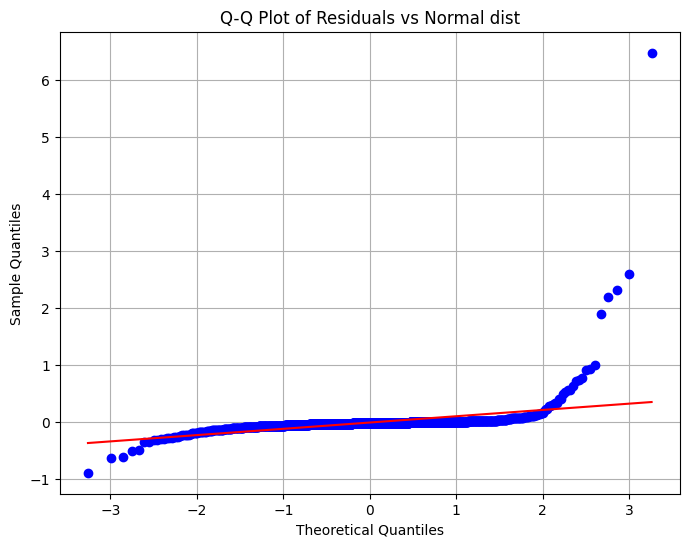

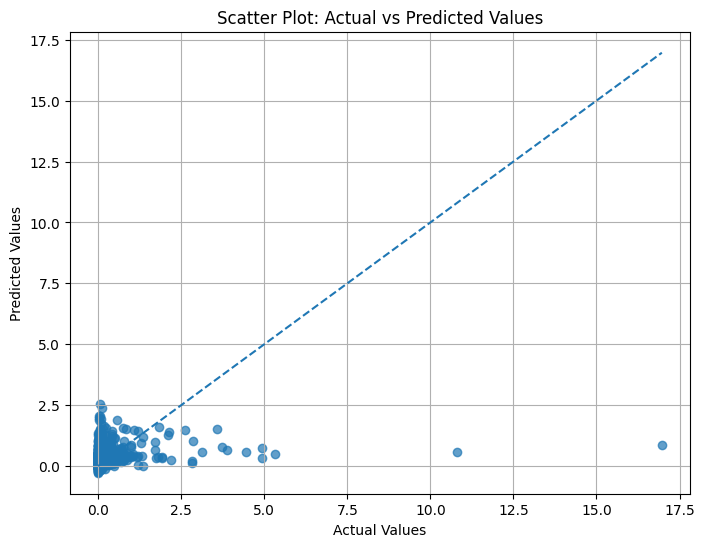

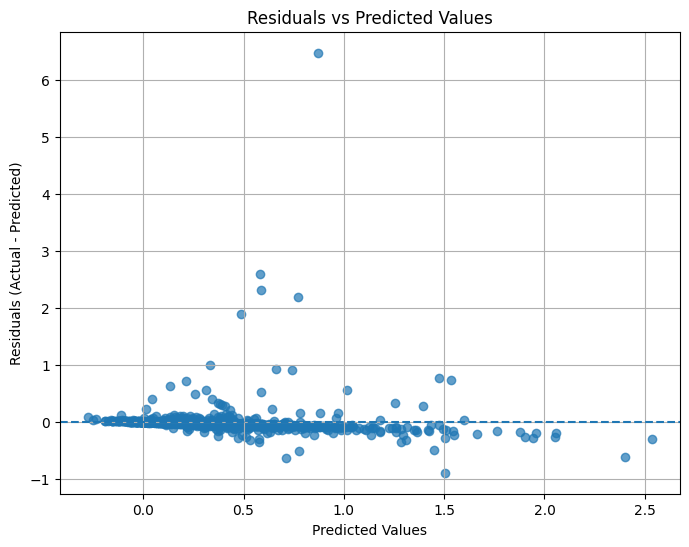

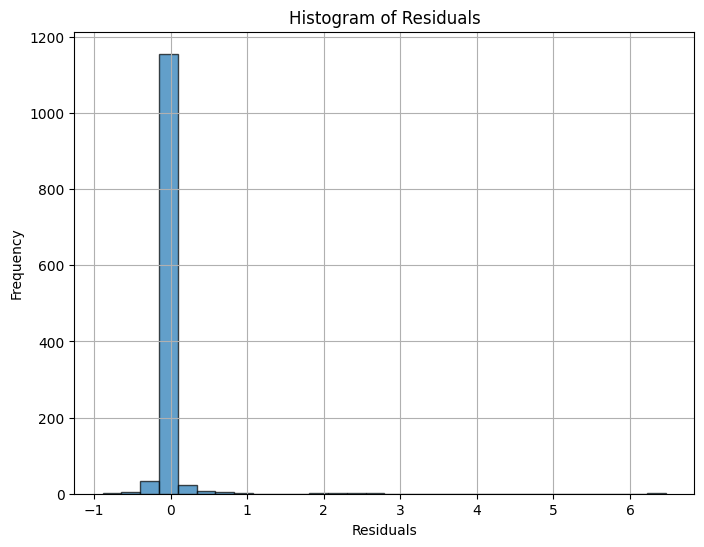

<Figure size 1000x800 with 0 Axes>

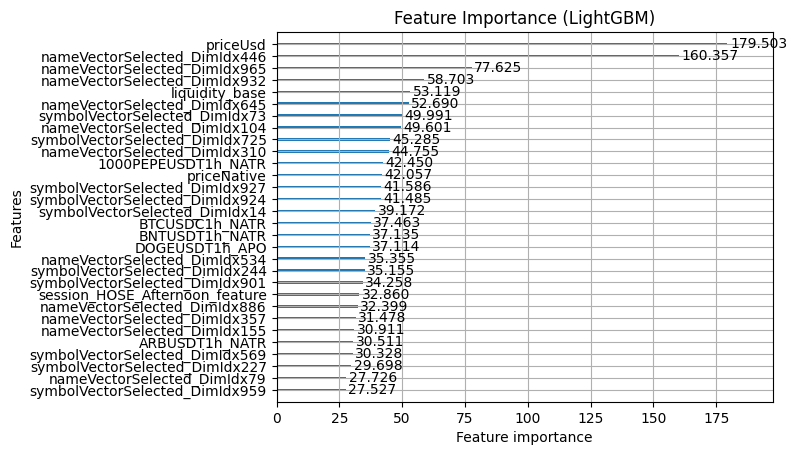

In [13]:
# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals vs Normal dist")
plt.xlabel("Theoretical Quantiles"); plt.ylabel("Sample Quantiles")
plt.grid(True); plt.show()

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
diagonal_min, diagonal_max = float(np.min(y_test)), float(np.max(y_test))
plt.plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], linestyle='--')
plt.xlabel('Actual Values'); plt.ylabel('Predicted Values')
plt.title('Scatter Plot: Actual vs Predicted Values')
plt.grid(True); plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Values'); plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.grid(True); plt.show()

# Histogram of Residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals'); plt.xlabel('Residuals'); plt.ylabel('Frequency')
plt.grid(True); plt.show()

# Feature importance
plt.figure(figsize=(10, 8))
lgbm.plot_importance(default_lgbm_model, importance_type='gain', max_num_features=30)
plt.title("Feature Importance (LightGBM)")
plt.show()

# Optuna hiperparameter optimization

In [14]:
opt_cv = KFold(n_splits=HYPERPARAM_TUNING_NFOLDS, shuffle=True, random_state=RND_STATE)

## Sampler and pruner definition

In [15]:
sampler = TPESampler(
    seed=RND_STATE,
    multivariate=True,
    group=True,
    n_startup_trials=3,
    constant_liar=True,
)

pruner = HyperbandPruner(
    min_resource=1,
    max_resource='auto',
    reduction_factor=3
)

C:\Users\philipz\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
C:\Users\philipz\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
C:\Users\philipz\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(


## Define objective

In [18]:
def objective(trial):
    obj = trial.suggest_categorical(
    "objective",
    ["regression", "regression_l1", "poisson", "tweedie", "gamma", "huber", "fair"]
    )
    params = {
        **MODEL_STATIC_PARAMS,
        "n_estimators": trial.suggest_int("n_estimators", 100, 10_000),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.5, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 128),
        "max_depth": trial.suggest_int("max_depth", 2, 64),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 2, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 20),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 100.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 100.0),
        "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 100.0),
        "verbosity": -1,
    }
    params["objective"] = obj
    if params["objective"] == "tweedie":
        params["tweedie_variance_power"] = trial.suggest_float("tweedie_variance_power", 1.01, 1.99)
    elif params["objective"] == "huber":
        params["alpha"] = trial.suggest_float("alpha", 0.5, 0.99)  # Huber's delta-ish control
    elif params["objective"] == "fair":
        params["fair_c"] = trial.suggest_float("fair_c", 0.01, 10.0)

    # print(f'Testing params: {params}')
    rmse_values, step = [], 0
    for tr_idx, va_idx in opt_cv.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        w_tr, w_va = w_train.iloc[tr_idx], w_train.iloc[va_idx]
        try:
            _model = lgbm.LGBMRegressor(**params).fit(X_tr, y_tr, sample_weight=w_tr)
            rmse = root_mean_squared_error(y_va, _model.predict(X_va), sample_weight=w_va)
        except (lgbm.basic.LightGBMError, ValueError):
            raise optuna.TrialPruned()
        rmse_values.append(rmse)
        step += 1
        trial.report(rmse, step=step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    # print(f'CV results: {rmse_values}')
    return float(np.mean(rmse_values))

## Run study

In [19]:
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, timeout=TERMINATION_OPTUNA, show_progress_bar=True)

[I 2025-09-27 20:33:47,439] A new study created in memory with name: no-name-caeae9f3-92dd-4637-ae4d-78c80ce3f4bf


   0%|          | 00:00/30:00

[I 2025-09-27 20:34:18,008] Trial 0 finished with value: 1.2239982556175408 and parameters: {'objective': 'regression', 'n_estimators': 7328, 'learning_rate': 0.02133000994315426, 'num_leaves': 112, 'max_depth': 23, 'min_data_in_leaf': 139, 'feature_fraction': 0.709302900414231, 'bagging_fraction': 0.6023312741255857, 'bagging_freq': 0, 'lambda_l1': 59.752068408125304, 'lambda_l2': 93.99806962356013, 'min_gain_to_split': 96.5500840338481}. Best is trial 0 with value: 1.2239982556175408.
[I 2025-09-27 20:34:40,207] Trial 1 finished with value: 1.2218582781224618 and parameters: {'objective': 'gamma', 'n_estimators': 4763, 'learning_rate': 0.07763168362625525, 'num_leaves': 66, 'max_depth': 22, 'min_data_in_leaf': 29, 'feature_fraction': 0.7171949796258928, 'bagging_fraction': 0.9864615367246925, 'bagging_freq': 16, 'lambda_l1': 32.64839213089724, 'lambda_l2': 10.56547172956468, 'min_gain_to_split': 22.004639720674046}. Best is trial 1 with value: 1.2218582781224618.
[I 2025-09-27 20:35:

In [20]:
BEST_PARAMS = study.best_trial.params
BEST_PARAMS = {**MODEL_STATIC_PARAMS, **study.best_trial.params}
print("Best params:", BEST_PARAMS)

Best params: {'seed': 37, 'device_type': 'gpu', 'objective': 'poisson', 'n_estimators': 9137, 'learning_rate': 0.16928014698722446, 'num_leaves': 107, 'max_depth': 47, 'min_data_in_leaf': 77, 'feature_fraction': 0.8118098788368369, 'bagging_fraction': 0.5740105922306286, 'bagging_freq': 15, 'lambda_l1': 2.404328099012785, 'lambda_l2': 20.80590023885008, 'min_gain_to_split': 0.11459437238291037}


## Fit

In [21]:
opt_lgbm_model = lgbm.LGBMRegressor(**BEST_PARAMS)
opt_lgbm_model.fit(X_train, y_train, sample_weight=w_train)

os.makedirs("models", exist_ok=True)
joblib.dump(opt_lgbm_model, "models/opt_reg_model.joblib")

['models/opt_reg_model.joblib']

## Analyse

In [22]:
y_pred = opt_lgbm_model.predict(X_test)

In [23]:
for name, scorer in SCORERS.items():
    print(f"{name} weighted   = {scorer(y_test, y_pred, sample_weight=w_test):.4f}")

rmse weighted   = 1.2925
mae weighted   = 0.5205
r2 weighted   = 0.0874


In [24]:
rmse = root_mean_squared_error(y_test, y_pred, sample_weight=w_test)
mae = mean_absolute_error(y_test, y_pred, sample_weight=w_test)
r2 = r2_score(y_test, y_pred, sample_weight=w_test)
DF_SCORES = pd.DataFrame({"Type": ["opt"], "RMSE": [rmse], "MAE": [mae], "R2": [r2]})
print(DF_SCORES)

  Type      RMSE       MAE        R2
0  opt  1.292523  0.520454  0.087447


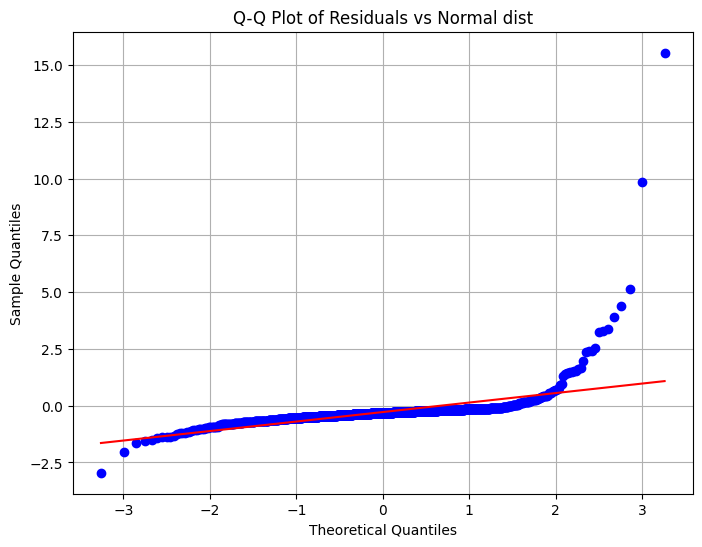

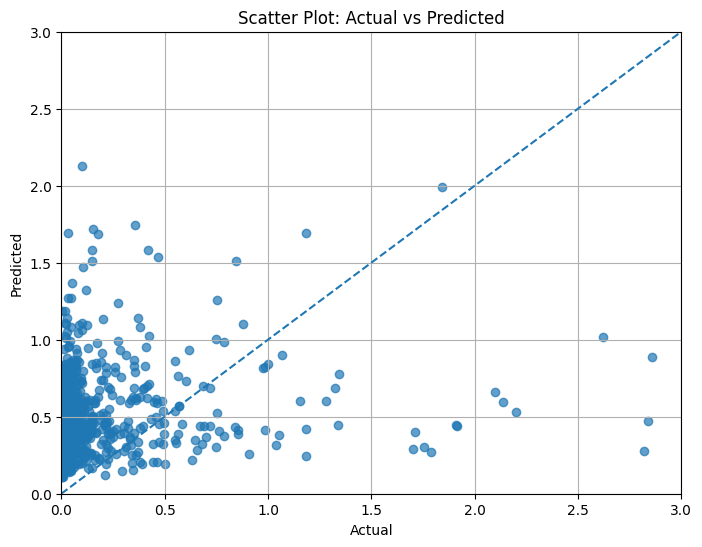

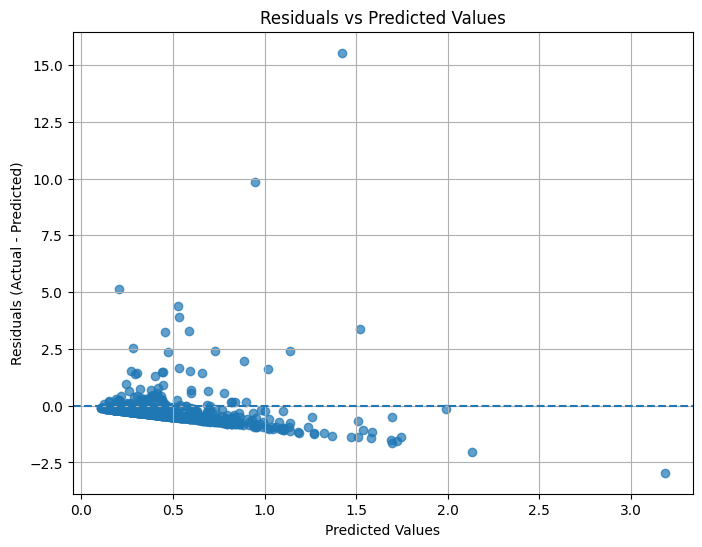

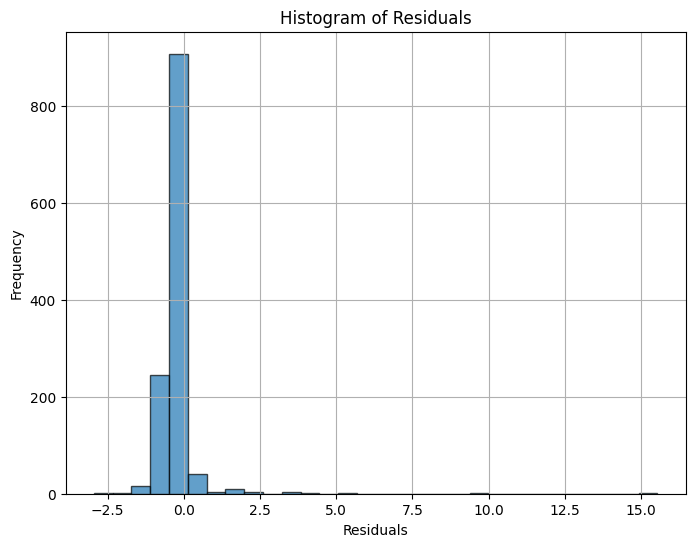

<Figure size 1000x800 with 0 Axes>

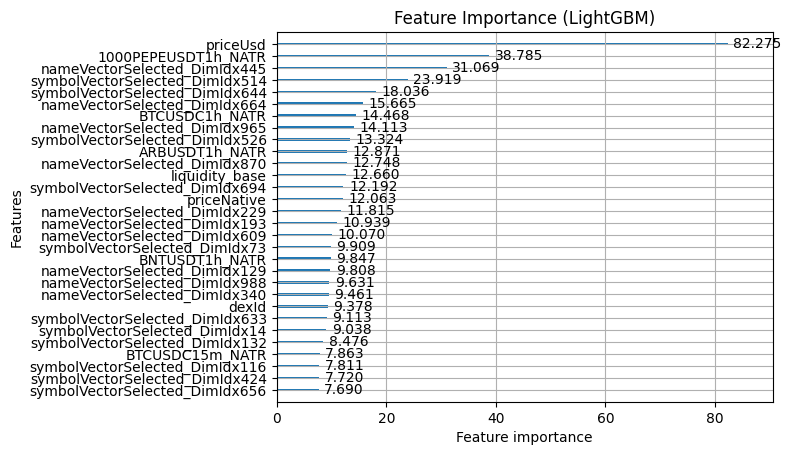

In [31]:
# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals vs Normal dist")
plt.xlabel("Theoretical Quantiles"); plt.ylabel("Sample Quantiles")
plt.grid(True); plt.show()

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 3], [0, 3], linestyle='--')
plt.xlim(0, 3); plt.ylim(0, 3)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Scatter Plot: Actual vs Predicted')
plt.grid(True); plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Values'); plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.grid(True); plt.show()

# Histogram of Residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals'); plt.xlabel('Residuals'); plt.ylabel('Frequency')
plt.grid(True); plt.show()

# Feature importance
plt.figure(figsize=(10, 8))
lgbm.plot_importance(opt_lgbm_model, importance_type='gain', max_num_features=30)
plt.title("Feature Importance (LightGBM)")
plt.show()

# Genetic optimization

## Define problem class

In [14]:
# class XGBoostOptimizationProblem(ElementwiseProblem):
#     def __init__(self, x_data, y_data, w_data, scorer, cv_folds=5, rnd_state=None, **kwargs):
#         self.x_data = x_data
#         self.y_data = y_data
#         self.w_data = w_data
#         self.cv_folds = cv_folds
#         self.scorer = scorer # Should be R^2
#         self.rnd_state = rnd_state
#         self.eval_times = []

#         self.kf = KFold(n_splits=cv_folds, shuffle=True, random_state=rnd_state)
        
#         hyperparameters = {
#             # Podstawowe parametry uczenia
#             "learning_rate": Real(bounds=(0.001, 0.3)),
#             "n_estimators": Integer(bounds=(100, 2000)),
#             # "early_stopping_rounds": Integer(bounds=(5, 50)),
            
#             # Parametry kontrolujące strukturę drzewa
#             "max_depth": Integer(bounds=(2, 12)),
#             "min_child_weight": Integer(bounds=(1, 20)),
#             "max_delta_step": Integer(bounds=(0, 10)),
#             "gamma": Real(bounds=(0, 10)),
            
#             # Parametry próbkowania
#             "subsample": Real(bounds=(0.5, 1.0)),
#             "colsample_bytree": Real(bounds=(0.1, 1.0)),
#             "colsample_bylevel": Real(bounds=(0.2, 1.0)),
#             "colsample_bynode": Real(bounds=(0.2, 1.0)),
            
#             # Parametry regularyzacji
#             "reg_alpha": Real(bounds=(0, 50)),
#             "reg_lambda": Real(bounds=(0, 50)),
            
#             # Dodatkowe parametry (nowe)
#             "grow_policy": Choice(options=["depthwise", "lossguide"]),
#             "max_leaves": Integer(bounds=(0, 256)),
#             "max_bin": Integer(bounds=(32, 512)),
            
#             # Funkcja celu
#             "objective": Choice(options=[
#                 'reg:squarederror', 
#                 'reg:squaredlogerror', 
#                 'reg:gamma', 
#                 'reg:tweedie', 
#                 'reg:pseudohubererror', 
#                 'count:poisson'
#             ]),

#             "tweedie_variance_power": Real(bounds=(1, 2)),
#         }
        
#         super().__init__(vars=hyperparameters, n_obj=1, **kwargs)

#     def _evaluate(self, X, out, *args, **kwargs):
#         if X["objective"] != 'reg:tweedie':
#             eval_metric = OBJ_EVAL_METRICS[X["objective"]]
#         else:
#             eval_metric = f"tweedie-nloglik@{X['tweedie_variance_power']}"
#         start_time = time.time()
#         scores = []
        
#         # Pętla CV ręcznie, aby wykorzystać early stopping
#         for train_index, valid_index in self.kf.split(self.x_data):
#         # Use .iloc to index rows by integer positions instead of column names
#             X_train_fold = self.x_data.iloc[train_index]
#             y_train_fold = self.y_data.iloc[train_index]
#             w_train_fold = self.w_data.iloc[train_index]
    
#             X_valid_fold = self.x_data.iloc[valid_index]
#             y_valid_fold = self.y_data.iloc[valid_index]
#             w_valid_fold = self.w_data.iloc[valid_index]
            
#             model = xgb.XGBRegressor(
#                 device="cuda",
#                 tree_method='hist',
#                 random_state=self.rnd_state,
#                 eval_metric=eval_metric,
#                 **X
#             )
            
#             model.fit(
#                 X_train_fold, 
#                 y_train_fold, 
#                 sample_weight=w_train_fold,
#                 # eval_set=[(X_valid_fold, y_valid_fold)],
#                 # eval_sample_weight=[w_valid_fold],
#                 # early_stopping_rounds=X["early_stopping_rounds"],
#                 verbose=False
#             )
#             y_pred_fold = model.predict(X_valid_fold)

#             # # Compute residuals (unstandardized)
#             # residuals = y_valid_fold - y_pred_fold
            
#             # # Estimate the density of unstandardized residuals using KDE
#             # kde = gaussian_kde(residuals)
#             # kde_density = kde(residuals)
            
#             # # Compute standard deviation from residuals
#             # std_res = np.std(residuals)
            
#             # # Compute the reference density from a normal distribution with mean=0 and std computed from residuals
#             # normal_density = norm.pdf(residuals, loc=0, scale=std_res)
            
#             # # Compute the KL divergence using Monte Carlo integration (via sample mean)
#             # epsilon = 1e-10  # Small value to avoid log(0)
#             # kl_distance = np.mean(np.log((kde_density + epsilon) / (normal_density + epsilon)))
            
#             # # For evaluation, lower KL divergence is better, so we return its negative (i.e. higher score means better fit)
#             # score_fold = kl_distance

#             # distance = np.mean(np.abs(y_pred_fold - y_valid_fold) / np.sqrt(2))
#             # print(f'distance {distance}')
#             # Xs, yk = y_pred_fold.reshape(-1, 1), y_valid_fold-y_pred_fold
#             # X_design = np.hstack((np.ones((Xs.shape[0], 1)), Xs))

#             # # Compute the regression coefficients using the normal equation.
#             # coefficients = np.matmul(np.matmul(np.linalg.inv(np.matmul(X_design.T, X_design)), X_design.T), yk)
            
#             # # Unpack the coefficients: intercept and slope.
#             # matrix_intercept, matrix_slope = coefficients.ravel()
            
#             # print(f'matrix_intercept: {matrix_intercept}, matrix_slope: {matrix_slope}')
            
#             # lin_reg =  LinearRegression().fit(y_pred_fold.reshape(-1, 1), y_valid_fold-y_pred_fold)
#             # slope, intercept = lin_reg.coef_[0], lin_reg.intercept_
#             # print(f'intercept {intercept} slope {slope}')
            
#             # distance = np.abs(intercept) / np.sqrt(1 + slope**2)
#             # print(f"Distance from regression line to y = 0: {distance:.4f}")

#             # score_fold = weighted_mae_along_line(y_valid_fold, y_pred_fold, w_valid_fold)
#             score_fold = self.scorer(y_valid_fold, y_pred_fold, sample_weight=w_valid_fold)
#             scores.append(score_fold)

#         # As arthmetic >= geomethirc >= harmonic (means)
#         # It's better to use arthmetic when using distance scorer with regression problem
#         print(f'scores {scores}')
#         mean_score = np.mean(scores)
#         # mean_score = geometric_mean(scores) does not work with <=0
#         # mean_score = 0 if (np.array(scores) <= 0).any() else len(np.array(scores)) / np.sum(1 / np.array(scores))
        
#         eval_time = time.time() - start_time
#         self.eval_times.append(eval_time)
#         print(f'Params: {X}')
#         # print(f'scores {scores}')
#         print(f'Mean CV score: {mean_score}  Evaluation time: {eval_time:.2f}s (mean {np.mean(self.eval_times):.2f}s)')
#         print()
#         out["F"] = mean_score

## Run search

In [15]:
# # pool = Pool(cpu_count())
# # runner = StarmapParallelization(pool.starmap)

# problem = XGBoostOptimizationProblem(
#     X_train,
#     y_train,
#     w_train,
#     cv_folds=HYPERPARAM_TUNING_NFOLDS,
#     scorer=SCORERS[HYPERPARAM_TUNING_SCORER],
#     rnd_state=RND_STATE
# )
# algorithm = GA(
#     pop_size=HYPERPARAM_TUNING_POPSIZE,
#     sampling=MixedVariableSampling(),
#     mating=MixedVariableMating(
#         eliminate_duplicates=MixedVariableDuplicateElimination()
#     ),
#     eliminate_duplicates=MixedVariableDuplicateElimination(),
# )

# res = minimize(
#     problem,
#     algorithm,
#     termination=TERMINATION,
#     verbose=True,
# )

scores [1.3246320000145764, 1.522288306031603, 1.5557655736199907, 1.4969087312264935, 1.7727741951335412, 1.6947863100727356, 1.502053991963536, 1.634744601025643]
Params: {'learning_rate': 0.003757336586029424, 'n_estimators': 1334, 'max_depth': 9, 'min_child_weight': 19, 'max_delta_step': 0, 'gamma': 9.547938380949205, 'subsample': 0.8573615834306527, 'colsample_bytree': 0.6884863247835393, 'colsample_bylevel': 0.30170472539953447, 'colsample_bynode': 0.8971692591497404, 'reg_alpha': 20.141009443221396, 'reg_lambda': 2.910038004928156, 'grow_policy': 'depthwise', 'max_leaves': 240, 'max_bin': 389, 'objective': 'count:poisson', 'tweedie_variance_power': 1.1494609584239406}
Mean CV score: 1.5629942136360149  Evaluation time: 28.40s (mean 28.40s)

scores [1.378124558304917, 1.6323194051855434, 1.6642307965549221, 1.5944007564894673, 1.8799370030411575, 1.7818317417464886, 1.5780586186706147, 1.7032756813910537]
Params: {'learning_rate': 0.03453888285374573, 'n_estimators': 1860, 'max_d

In [16]:
if len(res.F) == 1:
    if isinstance(res.X, dict):
        print(f"Best gene: score= {res.f} variables= {res.X.items()}")
    else:
        print(f"Best gene: score= {res.f} variables= {res.X}")
else:
    print("Pareto front:")
    for front, var in zip(res.F, res.X):
        print(f"front=", front, "variables=", list(var.values()))

Best gene: score= 1.200702120074465 variables= dict_items([('learning_rate', 0.05008519318105889), ('gamma', 0.06358916587568031), ('subsample', 0.630338070943441), ('colsample_bytree', 0.9215292948540835), ('colsample_bylevel', 0.9227031100673028), ('colsample_bynode', 0.6105640330520312), ('reg_alpha', 2.5833173034492174), ('reg_lambda', 0.7378456000605808), ('tweedie_variance_power', 1.85149100995523), ('n_estimators', 1990), ('max_depth', 8), ('min_child_weight', 11), ('max_delta_step', 7), ('max_leaves', 239), ('max_bin', 231), ('grow_policy', 'lossguide'), ('objective', 'reg:squarederror')])


## Fit tuned model

In [17]:
# if res.X["objective"] != 'reg:tweedie':
#     eval_metric = OBJ_EVAL_METRICS[res.X["objective"]]
# else:
#     eval_metric = f"tweedie-nloglik@{res.X['tweedie_variance_power']}"

# tuned_xgb_model = xgb.XGBRegressor(device="cuda",
#                                 seed=RND_STATE,
#                                 eval_metric=eval_metric,
#                                 tree_method='hist',
#                                 verbosity=2,
#                                 **res.X
#                                )

# tuned_xgb_model.fit(X_train, 
#                     y_train, 
#                     sample_weight=w_train,
#                    )
# joblib.dump(tuned_xgb_model, "models/tuned_reg_model.joblib")

[12:22:18] INFO: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\data\simple_dmatrix.cc:139: Generating new Ellpack page.


['models/tuned_reg_model.joblib']

In [18]:
# y_pred = tuned_xgb_model.predict(X_test)

# # Calculate residuals between actual and predicted values
# residuals = y_test - y_pred

In [19]:
# # sorted(y_pred, reverse=True)
# np.quantile(y_pred, [0.25, 0.5, 0.75, 0.95, 0.99, 1.])

array([2.18691623, 3.23502803, 4.29936945, 5.17126644, 5.63865142,
       6.20106792])

In [20]:
# np.mean(y_pred)

3.1985674

## Examine results

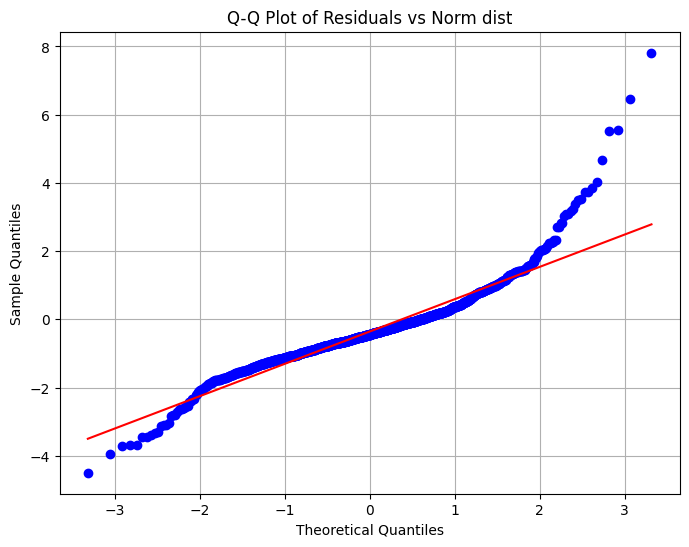

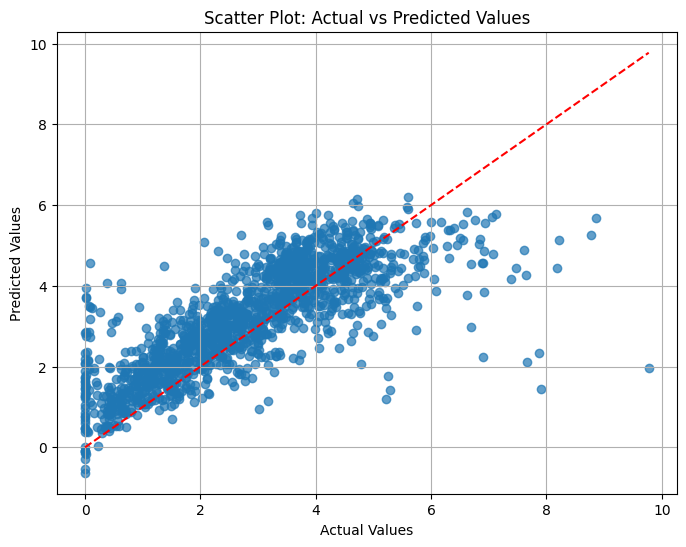

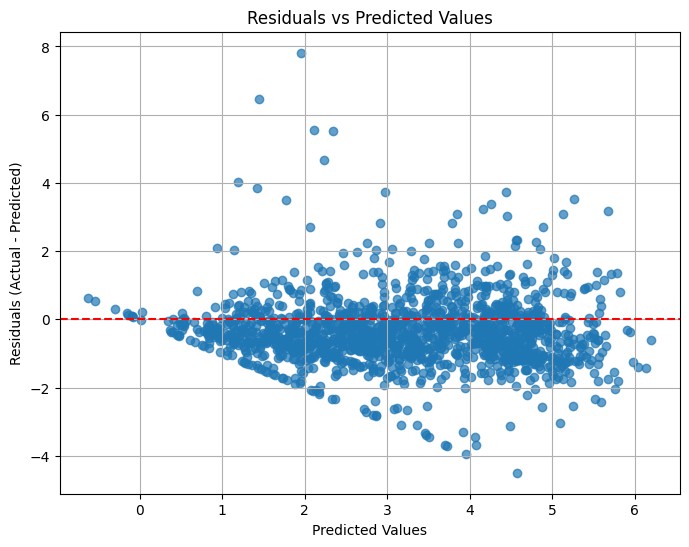

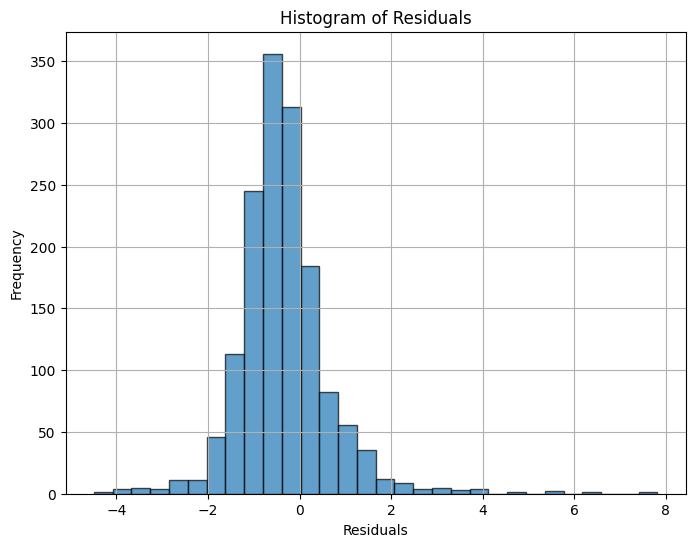

In [21]:
# # Create a Q-Q plot for the residuals to assess their normality
# plt.figure(figsize=(8, 6))
# stats.probplot(residuals, dist="norm", plot=plt)
# plt.title("Q-Q Plot of Residuals vs Norm dist")
# plt.xlabel("Theoretical Quantiles")
# plt.ylabel("Sample Quantiles")
# plt.grid(True)
# plt.show()

# # 1. Scatter Plot: Actual vs Predicted Values
# plt.figure(figsize=(8, 6))
# plt.scatter(y_test, y_pred, alpha=0.7)
# plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
# plt.xlabel('Actual Values')
# plt.ylabel('Predicted Values')
# plt.title('Scatter Plot: Actual vs Predicted Values')
# plt.grid(True)
# plt.show()

# # 2. Residuals vs Predicted Values Plot
# plt.figure(figsize=(8, 6))
# plt.scatter(y_pred, residuals, alpha=0.7)
# plt.axhline(0, color='red', linestyle='--')
# plt.xlabel('Predicted Values')
# plt.ylabel('Residuals (Actual - Predicted)')
# plt.title('Residuals vs Predicted Values')
# plt.grid(True)
# plt.show()

# # 3. Histogram of Residuals
# plt.figure(figsize=(8, 6))
# plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
# plt.title('Histogram of Residuals')
# plt.xlabel('Residuals')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

<Figure size 1000x800 with 0 Axes>

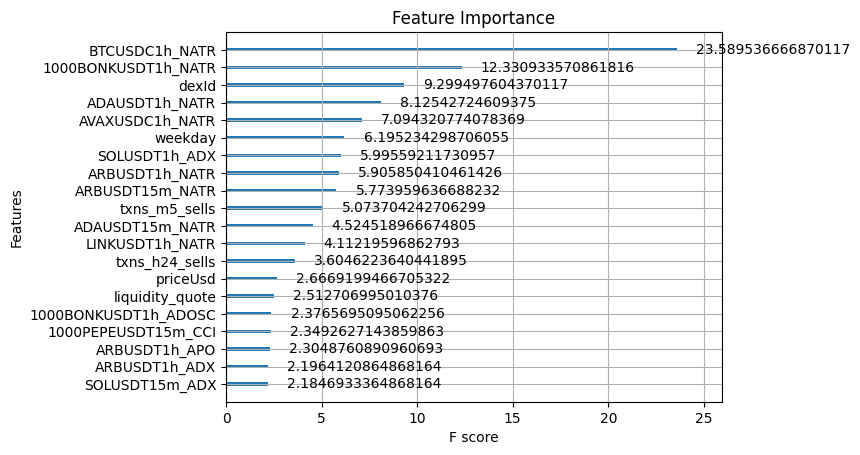

In [22]:
# Plot feature importance using the trained model
plt.figure(figsize=(10, 8))
xgb.plot_importance(tuned_xgb_model, importance_type='gain', max_num_features=20)
plt.title("Feature Importance")
plt.show()

# Final model

In [32]:
X_train_final, X_test_final, y_train_final, y_test_final, w_train_final, w_test_final = train_test_split(
    X, y, w, test_size=0.01, random_state=RND_STATE
)

## Train

In [35]:
if BEST_PARAMS is not None:
    final_lgbm_model = lgbm.LGBMRegressor(**BEST_PARAMS)
else:
    final_lgbm_model = lgbm.LGBMRegressor(**MODEL_STATIC_PARAMS)

final_lgbm_model.fit(X_train_final, 
                     y_train_final, 
                     sample_weight=w_train_final)
joblib.dump(default_lgbm_model, "models/final_reg_model.joblib")

['models/final_reg_model.joblib']

In [37]:
y_pred = final_lgbm_model.predict(X_test_final)

# Calculate residuals between actual and predicted values
residuals = y_test_final - y_pred

## Examine results

In [38]:
# sorted(y_pred, reverse=True)
np.quantile(y_pred, [0.25, 0.5, 0.75, 0.95, 0.99, 1.])

array([0.26103171, 0.38582692, 0.53025025, 0.91587292, 1.09865206,
       1.93812302])

In [39]:
np.mean(y_pred)

np.float64(0.4435501527452584)

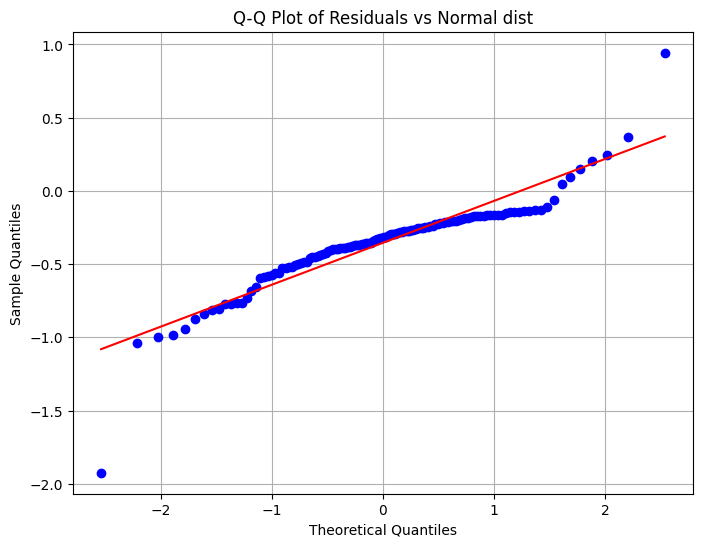

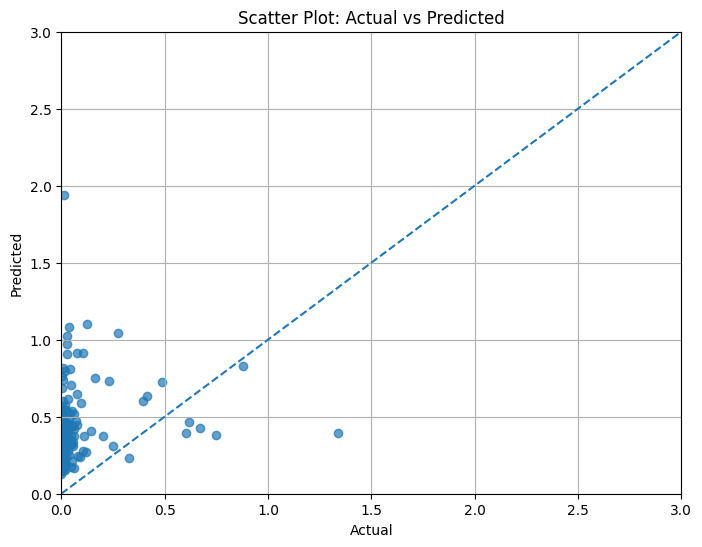

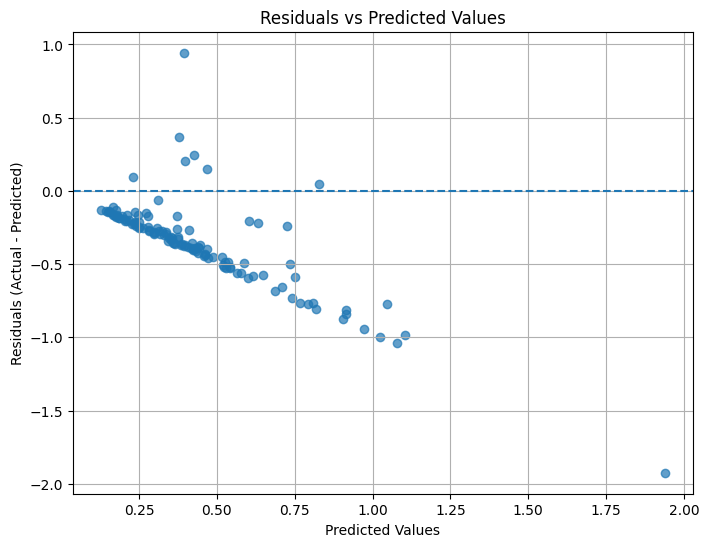

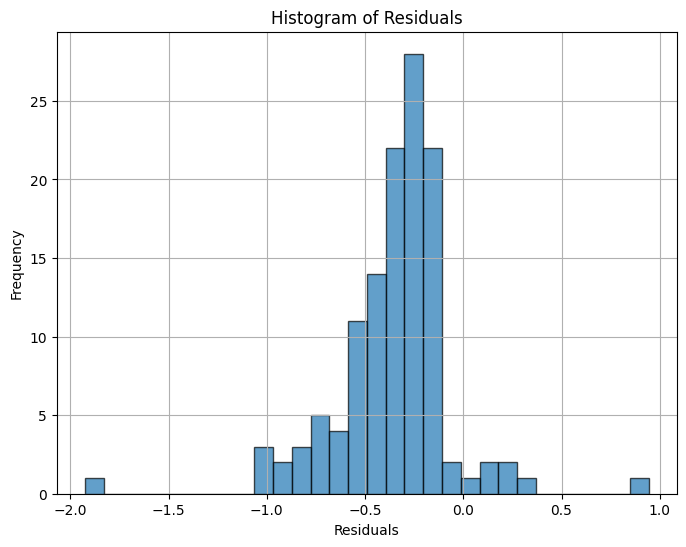

<Figure size 1000x800 with 0 Axes>

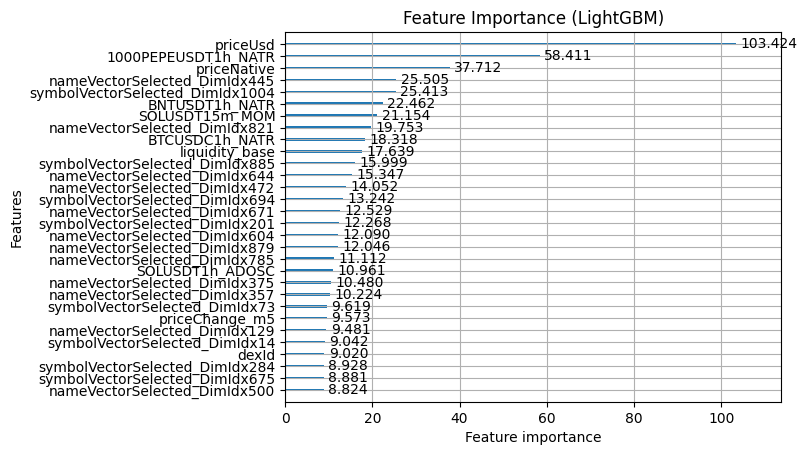

In [41]:
# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals vs Normal dist")
plt.xlabel("Theoretical Quantiles"); plt.ylabel("Sample Quantiles")
plt.grid(True); plt.show()

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_final, y_pred, alpha=0.7)
plt.plot([0, 3], [0, 3], linestyle='--')
plt.xlim(0, 3); plt.ylim(0, 3)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Scatter Plot: Actual vs Predicted')
plt.grid(True); plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Values'); plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.grid(True); plt.show()

# Histogram of Residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals'); plt.xlabel('Residuals'); plt.ylabel('Frequency')
plt.grid(True); plt.show()

# Feature importance
plt.figure(figsize=(10, 8))
lgbm.plot_importance(final_lgbm_model, importance_type='gain', max_num_features=30)
plt.title("Feature Importance (LightGBM)")
plt.show()

<Figure size 1000x800 with 0 Axes>

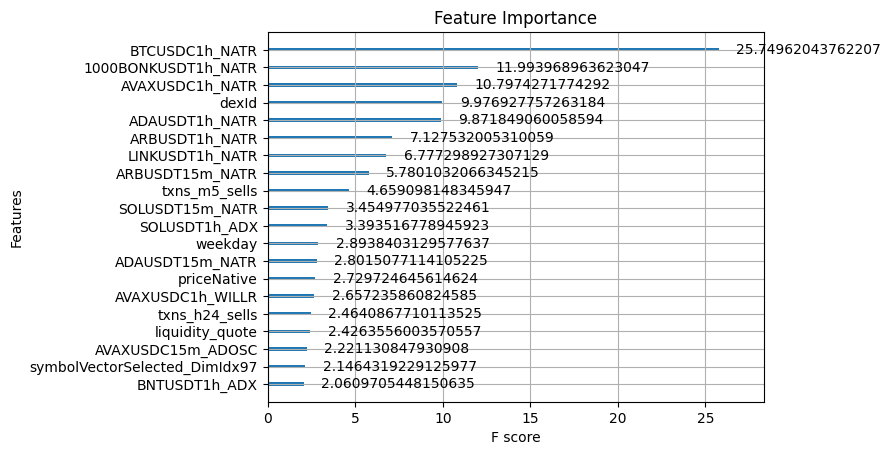

In [29]:
# Plot feature importance using the trained model
plt.figure(figsize=(10, 8))
xgb.plot_importance(final_xgb_model, importance_type='gain', max_num_features=20)
plt.title("Feature Importance")
plt.show()

# Optimize dataset balancer

## Run search

In [30]:
# best_metric = -1
# best_method = None
# best_pipeline = None
# results = []

# for method_name, sampler in BALANCE_METHODS.items():
#     pipeline = ImbPipeline([
#         ('sampler', sampler),
#         ('model', xgb.XGBRegressor(device="cuda",
#                                 seed=RND_STATE,
#                                 eval_metric='rmse',
#                                 tree_method='hist',
#                                 verbosity=2,
#                                 **res.X
#                                ))
#     ])
    
#     cv = KFold(n_splits=5, shuffle=True, random_state=RND_STATE)
    
#     cv_results = cross_validate(
#         estimator=pipeline,
#         X=X_train,
#         y=y_train,
#         cv=cv,
#         scoring=SCORERS,
#         return_train_score=False,
#         n_jobs=1
#     )
#     mean_scores = {
#         'rmse': np.mean(cv_results['test_rmse']),
#         'mae': np.mean(cv_results['test_mae']),
#         'r2': np.mean(cv_results['test_r2'])
#     }
    
#     results.append({
#         "Method": method_name,
#         **mean_scores
#     })
    
#     print(f"Metoda: {method_name}")
#     print(f"CV rmse: {mean_scores['rmse']:.4f}, mae: {mean_scores['mae']:.4f}, r2: {mean_scores['r2']:.4f}\n")
    
#     if mean_scores[BALANCER_SCORER] > best_metric:
#         best_metric = mean_scores[BALANCER_SCORER]
#         best_method = method_name
#         best_pipeline = pipeline

## Examine results

In [31]:
# # Podsumowanie wyników
# balancer_results = pd.DataFrame(results).sort_values(by=BALANCER_SCORER, ascending=False)
# print("\nPodsumowanie wyników walidacji krzyżowej:")
# print(balancer_results)

In [32]:
# # Predict on the test set
# y_pred = tuned_xgb_model.predict(X_test)
# y_pred_proba = tuned_xgb_model.predict_proba(X_test)[:, 1]

# # Calculate evaluation metrics
# f1 = f1_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred, zero_division=0)
# recall = recall_score(y_test, y_pred, zero_division=0)
# roc_auc = roc_auc_score(y_test, y_pred_proba)
# pr_auc = average_precision_score(y_test, y_pred_proba)
# mcc = matthews_corrcoef(y_test, y_pred)
# balanced_acc = balanced_accuracy_score(y_test, y_pred)

# # Print the metrics
# print("SCORES:")
# print(f"F1 Score:          {f1:.4f}")
# print(f"MCC:               {mcc:.4f}")
# print(f"PR AUC:            {pr_auc:.4f}")
# print(f"Balanced Accuracy: {balanced_acc:.4f}")
# print(f"Precision:         {precision:.4f}")
# print(f"Recall:            {recall:.4f}")
# print(f"AUC:               {roc_auc:.4f}")

# # Display confusion matrix and classification report
# cm = confusion_matrix(y_test, y_pred)
# print("\nConfusion Matrix:")
# print(cm)
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# # Plot confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot()
# plt.title("Confusion Matrix")
# plt.show()

# # Plot ROC curve
# fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
# roc_auc_curve = auc(fpr, tpr)

# plt.figure()
# plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc_curve:.2f})")
# plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
# plt.legend(loc="lower right")
# plt.show()

In [33]:
# plt.figure(figsize=(10, 8))
# plot_importance(
#     tuned_xgb_model, max_num_features=25, importance_type="weight", show_values=True
# )
# plt.title("Top 20 Most Important Features (XGBoost)")
# plt.show()